# Lung Cancer T-cell scRNA-seq: Load, Extract, and Reprocess

Standalone pipeline (no external agent-framework dependency) that:

1. **Loads** an original single-cell h5ad dataset from one of three sources you choose in the Parameters cell:
   - a **CELLxGENE Census** `dataset_id` (queries and downloads only the matching cells, e.g. the LuCA lung cancer atlas)
   - a **remote URL** to an `.h5ad` file (e.g. a CELLxGENE Explorer "Download Dataset" link)
   - a **local file path** to an `.h5ad` file already on disk
2. **Extracts T cells** from that data (by `cell_type` obs column, if the loaded object contains more than just T cells)
3. **Reprocesses** from raw counts: QC filtering -> normalization -> HVG/PCA -> Harmony batch correction -> neighbor graph -> UMAP -> Leiden clustering
4. **Annotates** clusters into biological T-cell subsets (naive/Tcm, Treg, effector memory, terminal effector, exhausted, proliferating, etc.)
5. **Visualizes**: UMAP colored by subset, a marker-gene heatmap, and a marker-gene dot plot

Every function is defined directly in this notebook. It depends only on
`scanpy`, `harmonypy`, `cellxgene_census`, `pandas`, `numpy`, `scipy`,
`matplotlib`, and `requests` — no Biomni or other agent-framework import.


## 1. Imports

In [1]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib as mpl
import matplotlib.pyplot as plt

sc.settings.verbosity = 1


def apply_figure_style(*, frame="open", font=None, sizes=(8, 7, 6), grid=False):
    """Set matplotlib rcParams for publication-grade output. Call once before plotting.

    Self-contained copy (no external dependency) of the house figure-style helper:
    role-mapped font-size ladder, outward ticks, frameless legends, 300-dpi save,
    Type-42 embedded fonts. frame='open' (bottom+left spines) | 'boxed' (all four)
    | 'none'. sizes=(base, secondary, tick) for titles/axis-labels, legend, ticks.
    """
    if frame not in ("open", "boxed", "none"):
        raise ValueError(f"frame must be 'open'|'boxed'|'none', got {frame!r}")
    base, secondary, tick = sizes
    boxed = (frame == "boxed")
    rc = {
        "font.family": "sans-serif",
        "font.size": base,
        "axes.labelsize": base,
        "axes.titlesize": base,
        "legend.fontsize": secondary,
        "xtick.labelsize": tick,
        "ytick.labelsize": tick,
        "axes.linewidth": 0.6,
        "xtick.direction": "out", "ytick.direction": "out",
        "xtick.major.size": 3, "ytick.major.size": 3,
        "xtick.major.width": 0.6, "ytick.major.width": 0.6,
        "axes.spines.top": boxed, "axes.spines.right": boxed,
        "axes.spines.left": frame != "none", "axes.spines.bottom": frame != "none",
        "axes.grid": bool(grid),
        "legend.frameon": False,
        "figure.dpi": 200,
        "savefig.dpi": 300,
        "savefig.bbox": "tight",
        "axes.titleweight": "normal",
        "axes.titlelocation": "left",
        "axes.labelweight": "normal",
        "lines.linewidth": 1.2,
        "patch.linewidth": 0.6,
        "pdf.fonttype": 42, "ps.fonttype": 42,
    }
    if font:
        rc["font.sans-serif"] = [font, "DejaVu Sans"]
    mpl.rcParams.update(rc)


apply_figure_style()


## 2. Parameters — edit this cell for your run

Set `DATA_SOURCE` to one of `"census"`, `"url"`, or `"local"`, and fill in the
matching value below. Everything downstream reads from these variables only.

In [2]:
# --- Choose ONE data source -------------------------------------------------
DATA_SOURCE = "census"   # "census" | "url" | "local"

# Used when DATA_SOURCE == "census": a CELLxGENE Census dataset_id (UUID).
# Example below is the LuCA lung cancer atlas (Salcher et al.).
CENSUS_DATASET_ID = "232f6a5a-a04c-4758-a6e8-88ab2e3a6e69"
CENSUS_VERSION = "stable"

# Used when DATA_SOURCE == "url": a direct HTTP(S) link to an .h5ad file
# (e.g. a CELLxGENE Explorer "Download Dataset" URL -- NOT a browse-page URL).
REMOTE_H5AD_URL = "https://datasets.cellxgene.cziscience.com/<uuid>.h5ad"

# Used when DATA_SOURCE == "local": a path to an .h5ad file already on disk.
LOCAL_H5AD_PATH = "luca_tcells_raw.h5ad"

# --- T-cell extraction filter (applied after loading, if the obs column exists) ---
CELL_TYPE_COLUMN = "cell_type"
T_CELL_TYPES = [
    "CD4-positive, alpha-beta T cell",
    "CD8-positive, alpha-beta T cell",
    "regulatory T cell",
    "T cell",
]
TISSUE_COLUMN = "tissue"
TISSUE_FILTER = None          # e.g. "lung"; None = no tissue filter
DISEASE_COLUMN = "disease"
DISEASE_EXCLUDE = ["chronic obstructive pulmonary disease"]  # disease values to drop before
                               # balancing -- COPD is a chronic inflammatory condition, not a
                               # cancer group, so it's excluded from this tumor-vs-normal analysis.
                               # Set to [] to keep every disease value found in the data.
BALANCE_BY = "disease"        # obs column to balance downsampling across, or None
MAX_CELLS_PER_GROUP = 3500    # cap per BALANCE_BY group; used for "census" source
MAX_CELLS_TOTAL = None        # uniform cap on total cells; used for "url"/"local" sources
RANDOM_SEED = 0

# --- QC / processing parameters --------------------------------------------
BATCH_KEY = "assay"                 # obs column for Harmony batch correction; None to skip
MIN_GENES = 200
MIN_CELLS = 3
MAX_TOTAL_COUNTS_QUANTILE = 0.995
DROP_ASSAY_VALUES = ["Smart-seq2"]  # non-UMI assays, not magnitude-comparable; [] to keep all
N_TOP_GENES = 2000
N_PCS = 50
N_NEIGHBORS = 15
LEIDEN_RESOLUTION = 1.0

# --- Output paths ------------------------------------------------------------
RAW_H5AD_OUT = "notebook_tcells_raw.h5ad"
PROCESSED_H5AD_OUT = "notebook_tcells_processed.h5ad"
ANNOTATED_H5AD_OUT = "notebook_tcells_annotated.h5ad"
UMAP_PNG_OUT = "notebook_umap_by_subset.png"
HEATMAP_PNG_OUT = "notebook_marker_heatmap.png"
DOTPLOT_PNG_OUT = "notebook_marker_dotplot.png"

# --- Marker gene panel for visualization -------------------------------------
MARKER_GENES = [
    "CCR7", "SELL", "TCF7", "IL7R",                 # naive / Tcm
    "FOXP3", "CTLA4", "IL2RA",                      # regulatory T
    "GZMK", "GZMA",                                 # effector memory
    "GZMH", "GZMB", "GNLY", "NKG7", "PRF1",         # cytotoxic / terminal effector
    "CXCL13", "HAVCR2", "PDCD1", "LAG3", "TIGIT",   # exhaustion
    "MKI67",                                        # proliferation
    "KLRB1", "KLRC1",                               # innate-like
]

print(f"DATA_SOURCE = {DATA_SOURCE!r}")


DATA_SOURCE = 'census'


## 3. Load the original data

Exactly one of the three branches below runs, based on `DATA_SOURCE`.

In [3]:
if DATA_SOURCE == "census":
    import cellxgene_census
    import tiledbsoma
    from urllib.parse import urlparse

    # If an HTTP(S) proxy is configured in the environment (common on sandboxed/
    # firewalled compute), point TileDB's S3 VFS at it explicitly -- it does not
    # pick up HTTP_PROXY/HTTPS_PROXY automatically. No-op (plain open_soma) when
    # no proxy env var is set, so this is safe on an unrestricted machine too.
    proxy_url = os.environ.get("HTTPS_PROXY") or os.environ.get("https_proxy") \
        or os.environ.get("HTTP_PROXY") or os.environ.get("http_proxy")
    if proxy_url:
        p = urlparse(proxy_url)
        soma_ctx = tiledbsoma.SOMATileDBContext(tiledb_config={
            "vfs.s3.proxy_host": p.hostname,
            "vfs.s3.proxy_port": p.port or 0,
            "vfs.s3.proxy_scheme": p.scheme or "http",
        })
        print(f"Using S3 proxy {p.hostname}:{p.port} for Census access (from {proxy_url!r} env var).")
    else:
        soma_ctx = None

    census = cellxgene_census.open_soma(census_version=CENSUS_VERSION, context=soma_ctx)
    obs_df = cellxgene_census.get_obs(
        census, "homo_sapiens",
        value_filter=f"dataset_id == '{CENSUS_DATASET_ID}'",
        column_names=["soma_joinid", CELL_TYPE_COLUMN, DISEASE_COLUMN, TISSUE_COLUMN, "assay", "sex"],
    )
    print(f"Dataset {CENSUS_DATASET_ID}: {len(obs_df)} total cells available.")

elif DATA_SOURCE == "url":
    import requests

    raw_path = LOCAL_H5AD_PATH if 'LOCAL_H5AD_PATH' in dir() else "downloaded.h5ad.tmp"
    raw_path = "downloaded_original.h5ad"
    with requests.get(REMOTE_H5AD_URL, stream=True, timeout=1800) as r:
        r.raise_for_status()
        content_type = r.headers.get("content-type", "")
        if "html" in content_type.lower():
            raise ValueError(
                f"URL {REMOTE_H5AD_URL!r} returned content-type {content_type!r} -- looks like an "
                "HTML landing page, not a direct h5ad download link."
            )
        with open(raw_path, "wb") as f:
            for chunk in r.iter_content(chunk_size=8 * 1024 * 1024):
                f.write(chunk)
    print(f"Downloaded {os.path.getsize(raw_path)/1e6:.1f} MB from {REMOTE_H5AD_URL} to {raw_path}")

elif DATA_SOURCE == "local":
    if not os.path.exists(LOCAL_H5AD_PATH):
        raise FileNotFoundError(f"LOCAL_H5AD_PATH not found: {LOCAL_H5AD_PATH}")
    print(f"Using local file: {LOCAL_H5AD_PATH} ({os.path.getsize(LOCAL_H5AD_PATH)/1e6:.1f} MB)")

else:
    raise ValueError(f"Unknown DATA_SOURCE: {DATA_SOURCE!r}")


Using S3 proxy localhost:3128 for Census access (from 'http://localhost:3128' env var).
Dataset 232f6a5a-a04c-4758-a6e8-88ab2e3a6e69: 892296 total cells available.


## 4. Extract T cells and build the raw AnnData

Before balancing, any `disease` value listed in `DISEASE_EXCLUDE` is dropped
from both branches (e.g. the LuCA atlas also contains a chronic obstructive
pulmonary disease (COPD) cohort alongside the tumor and normal-tissue
samples; COPD is a non-cancer chronic-inflammatory condition, not one of
the tumor-vs-normal groups this pipeline compares, so it's excluded by
default -- set `DISEASE_EXCLUDE = []` to keep every group in the data).

For the `"census"` source, the remaining cells are balance-downsampled across
`BALANCE_BY` (e.g. per-disease-group) at fetch time, so no single group
dominates downstream clustering. For `"url"`/`"local"` sources the whole
file is loaded first, then filtered/optionally downsampled uniformly.


In [4]:
if DATA_SOURCE == "census":
    mask = obs_df[CELL_TYPE_COLUMN].isin(T_CELL_TYPES)
    if TISSUE_FILTER is not None:
        mask &= obs_df[TISSUE_COLUMN].astype(str) == TISSUE_FILTER
    if DISEASE_EXCLUDE:
        mask &= ~obs_df[DISEASE_COLUMN].astype(str).isin(DISEASE_EXCLUDE)
    sub = obs_df[mask].copy()
    n_before = len(sub)
    if DISEASE_EXCLUDE:
        print(f"Excluded disease group(s) {DISEASE_EXCLUDE} before balancing.")

    np.random.seed(RANDOM_SEED)
    if BALANCE_BY is not None:
        parts = []
        for _, g in sub.groupby(sub[BALANCE_BY].astype(str)):
            n = min(MAX_CELLS_PER_GROUP, len(g))
            parts.append(g.sample(n=n, random_state=RANDOM_SEED))
        sel = pd.concat(parts)
    else:
        n = min(MAX_CELLS_PER_GROUP, len(sub)) if MAX_CELLS_PER_GROUP else len(sub)
        sel = sub.sample(n=n, random_state=RANDOM_SEED)

    adata = cellxgene_census.get_anndata(
        census, organism="homo_sapiens",
        obs_coords=sel.soma_joinid.tolist(),
        column_names={"obs": ["soma_joinid", CELL_TYPE_COLUMN, DISEASE_COLUMN, TISSUE_COLUMN,
                                "assay", "sex", "dataset_id", "self_reported_ethnicity", "donor_id"]},
    )
    print(f"Matched {n_before} T cells; balance-downsampled to {adata.n_obs} cells x {adata.n_vars} genes.")

else:
    src_path = raw_path if DATA_SOURCE == "url" else LOCAL_H5AD_PATH
    adata = sc.read_h5ad(src_path)
    n_loaded = adata.n_obs
    print(f"Loaded {n_loaded} cells x {adata.n_vars} genes from {src_path}.")

    if CELL_TYPE_COLUMN in adata.obs.columns:
        adata = adata[adata.obs[CELL_TYPE_COLUMN].astype(str).isin(T_CELL_TYPES)].copy()
        print(f"Extracted {adata.n_obs} T cells by '{CELL_TYPE_COLUMN}' (from {n_loaded}).")
    else:
        print(f"WARNING: '{CELL_TYPE_COLUMN}' not in obs columns -- assuming file already contains only T cells.")

    if TISSUE_FILTER is not None and TISSUE_COLUMN in adata.obs.columns:
        adata = adata[adata.obs[TISSUE_COLUMN].astype(str) == TISSUE_FILTER].copy()
        print(f"After tissue filter '{TISSUE_FILTER}': {adata.n_obs} cells.")

    if DISEASE_EXCLUDE and DISEASE_COLUMN in adata.obs.columns:
        adata = adata[~adata.obs[DISEASE_COLUMN].astype(str).isin(DISEASE_EXCLUDE)].copy()
        print(f"After excluding disease group(s) {DISEASE_EXCLUDE}: {adata.n_obs} cells.")

    if MAX_CELLS_TOTAL is not None and adata.n_obs > MAX_CELLS_TOTAL:
        rng = np.random.default_rng(RANDOM_SEED)
        idx = np.sort(rng.choice(adata.n_obs, size=MAX_CELLS_TOTAL, replace=False))
        adata = adata[idx].copy()
        print(f"Downsampled to {adata.n_obs} cells (MAX_CELLS_TOTAL={MAX_CELLS_TOTAL}).")

    if DATA_SOURCE == "url" and os.path.exists(raw_path):
        os.remove(raw_path)  # drop the full downloaded file once the T-cell subset is extracted

adata.write_h5ad(RAW_H5AD_OUT)
print(f"\nWrote raw T-cell AnnData to {RAW_H5AD_OUT}: {adata.n_obs} cells x {adata.n_vars} genes.")
adata


Excluded disease group(s) ['chronic obstructive pulmonary disease'] before balancing.
Matched 220742 T cells; balance-downsampled to 14000 cells x 61497 genes.

Wrote raw T-cell AnnData to notebook_tcells_raw.h5ad: 14000 cells x 61497 genes.


## 5. QC, normalization, batch correction, clustering, UMAP

Filters cells/genes, drops top total-count outliers and (optionally)
non-UMI assays, log-normalizes, selects highly variable genes, runs PCA,
corrects for batch effects with Harmony (if `BATCH_KEY` is set), builds a
neighbor graph on the batch-corrected space, and computes UMAP + Leiden
clusters.

In [5]:
adata.layers["counts"] = adata.X.copy()

# Use gene symbols as var_names if a feature_name column is present (Census convention)
if "feature_name" in adata.var.columns:
    adata.var_names = adata.var["feature_name"].astype(str)
    adata.var_names_make_unique()
    adata.var.index.name = None  # avoid feature_name being both index and column at write time

adata.var["mt"] = adata.var_names.str.startswith("MT-")
sc.pp.calculate_qc_metrics(adata, qc_vars=["mt"], inplace=True, percent_top=None)

n0 = adata.n_obs
sc.pp.filter_cells(adata, min_genes=MIN_GENES)
sc.pp.filter_genes(adata, min_cells=MIN_CELLS)

upper = adata.obs.total_counts.quantile(MAX_TOTAL_COUNTS_QUANTILE)
adata = adata[adata.obs.total_counts <= upper].copy()

if DROP_ASSAY_VALUES and "assay" in adata.obs.columns:
    adata = adata[~adata.obs.assay.astype(str).isin(DROP_ASSAY_VALUES)].copy()

print(f"QC: {n0} -> {adata.n_obs} cells retained "
      f"(min_genes={MIN_GENES}, total_counts<={MAX_TOTAL_COUNTS_QUANTILE:.3f} quantile"
      f"{', assay filter applied' if DROP_ASSAY_VALUES else ''}).")


QC: 14000 -> 13125 cells retained (min_genes=200, total_counts<=0.995 quantile, assay filter applied).


In [6]:
adata.X = adata.layers["counts"].copy()
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
adata.layers["lognorm"] = adata.X.copy()

hvg_kwargs = {"n_top_genes": N_TOP_GENES}
if BATCH_KEY is not None and BATCH_KEY in adata.obs.columns:
    hvg_kwargs["batch_key"] = BATCH_KEY
sc.pp.highly_variable_genes(adata, **hvg_kwargs)

adata.raw = adata  # keep full log-normalized matrix for marker plotting later

adata_hvg = adata[:, adata.var.highly_variable].copy()
sc.pp.scale(adata_hvg, max_value=10)
sc.tl.pca(adata_hvg, n_comps=N_PCS, svd_solver="arpack")
adata.obsm["X_pca"] = adata_hvg.obsm["X_pca"]

print(f"Selected {adata.var.highly_variable.sum()} HVGs; computed {N_PCS}-component PCA.")


Selected 2000 HVGs; computed 50-component PCA.


In [7]:
rep = "X_pca"
if BATCH_KEY is not None and BATCH_KEY in adata.obs.columns:
    import harmonypy

    ho = harmonypy.run_harmony(adata.obsm["X_pca"], adata.obs, [BATCH_KEY], max_iter_harmony=20)
    Zc = np.asarray(ho.Z_corr)
    adata.obsm["X_pca_harmony"] = Zc.T if Zc.shape[0] != adata.n_obs else Zc
    rep = "X_pca_harmony"
    print(f"Harmony batch correction applied on '{BATCH_KEY}'.")
else:
    print("Skipping Harmony batch correction (BATCH_KEY not set or not in obs).")

sc.pp.neighbors(adata, use_rep=rep, n_neighbors=N_NEIGHBORS)
sc.tl.umap(adata)
sc.tl.leiden(adata, resolution=LEIDEN_RESOLUTION, key_added="leiden", flavor="igraph", n_iterations=2)

cluster_counts = adata.obs.leiden.value_counts().sort_index()
print(f"Leiden (resolution={LEIDEN_RESOLUTION}) found {cluster_counts.shape[0]} clusters:")
print(cluster_counts)

adata.write_h5ad(PROCESSED_H5AD_OUT)
print(f"\nWrote processed AnnData (with UMAP + Leiden) to {PROCESSED_H5AD_OUT}.")


Harmony batch correction applied on 'assay'.
Leiden (resolution=1.0) found 17 clusters:
leiden
0     1035
1     2097
2     1969
3      974
4      569
5      127
6      872
7      632
8       74
9     1131
10    1555
11     204
12     424
13     756
14     318
15     261
16     127
Name: count, dtype: int64

Wrote processed AnnData (with UMAP + Leiden) to notebook_tcells_processed.h5ad.


## 6. Inspect clusters, then annotate biological subsets

Run this cell to see each cluster's size and mean expression of a few
canonical markers, to help you fill in `LABEL_MAP` below (or adjust the
default mapping if your cluster numbering differs from the reference run).

In [8]:
inspect_genes = [g for g in MARKER_GENES if g in adata.raw.var_names]
X_inspect = adata.raw[:, inspect_genes].X
X_inspect = X_inspect.toarray() if hasattr(X_inspect, "toarray") else X_inspect
inspect_df = pd.DataFrame(X_inspect, columns=inspect_genes, index=adata.obs_names)
inspect_df["leiden"] = adata.obs["leiden"].values
cluster_profile = inspect_df.groupby("leiden", observed=True).mean()
cluster_profile["n_cells"] = adata.obs["leiden"].value_counts()
cluster_profile


### 6b. Auto-suggest labels (signature scoring) — optional starting point

Typing `LABEL_MAP` by eye from the table above works, but doesn't scale
past a handful of clusters and doesn't reuse the marker knowledge already
encoded in `MARKER_GENES`. The cell below turns that same marker panel
into named **phenotype signatures** and scores every cluster against each,
with CD4/CD8 lineage determined **independently** rather than assumed:

1. For each gene, z-score its per-cluster mean expression across clusters
   (so genes on very different scales are comparable).
2. For each phenotype signature (e.g. `Regulatory (Treg)` = FOXP3+CTLA4+IL2RA),
   average the z-scores of its member genes -> a cluster x signature score
   matrix.
3. Separately, call CD4 vs CD8 **lineage** per cluster directly from raw
   CD4 vs CD8A/CD8B mean expression (not folded into the signature name).
4. Assign a cluster to its top-scoring phenotype only if that top score
   clears `score_threshold` (real enrichment, not just "least bad") **and**
   beats the runner-up by `margin_threshold` (not a coin-flip between two
   signatures), then prefix the independently-called lineage onto the
   label. Otherwise the cluster is left as `"Cluster <id> (unannotated)"`
   — the same safe fallback the manual map uses.
5. A small panel of QC-artifact gene sets (stress response, ambient
   hemoglobin/immunoglobulin, myeloid-doublet markers) is scored the same
   way; any cluster where one of these clears its own threshold is
   suggested as low-quality.

**Bug fixed here:** an earlier version of this cell hardcoded lineage into
the signature *name* itself (e.g. `"CD8 Exhausted/Tumor-reactive"`), so any
cluster scoring high on the exhaustion markers (CXCL13/PDCD1/LAG3/TIGIT/HAVCR2)
was labeled CD8 regardless of its actual CD4/CD8 expression. On this dataset
that mislabeled a real CD4+ CXCL13-high cluster (a CD4 "T peripheral-helper"-like
tumor-reactive phenotype, common in TIL infiltrates) as CD8. Lineage is now
called separately from raw CD4 vs CD8A/CD8B expression and only then combined
with the phenotype call, so the label reflects what the lineage markers
actually show rather than what the phenotype signature's name assumes.

This is a **suggestion, not ground truth** — on this dataset it recovers
4 of 5 previously hand-curated low-quality clusters and gives sensible
labels to every clearly-separated biological cluster, but calls clusters
sitting between two signatures (or two lineages) "unannotated"/lineage-blank
rather than forcing a call, and can over-flag small clusters as low-quality.
Inspect `suggestion_diagnostics` below, then edit `LABEL_MAP` /
`LOW_QUALITY_CLUSTERS` in the next cell — which starts from these
suggestions rather than a blank dict.


In [9]:
# Phenotype signatures (functional state only -- CD4/CD8 lineage is scored
# separately below and prefixed onto the label, rather than being hardcoded
# into a signature's name). This fixes a real bug found in the previous
# version: a CD4+ CXCL13-high cluster (T peripheral-helper-like, common in
# tumor infiltrates) was mislabeled "CD8 Exhausted/Tumor-reactive" purely
# because the exhaustion signature's name assumed CD8 -- the algorithm never
# actually checked CD4 vs CD8 marker expression before assigning that label.
PHENOTYPE_SIGNATURES = {
    "Naive/Tcm":                   "CCR7 SELL TCF7 IL7R".split(),
    "Regulatory (Treg)":           "FOXP3 CTLA4 IL2RA".split(),
    "Effector Memory (GZMK+)":     "GZMK GZMA".split(),
    "Terminal Effector":           "GZMH GZMB GNLY NKG7 PRF1".split(),
    "Exhausted/Tumor-reactive":    "CXCL13 HAVCR2 PDCD1 LAG3 TIGIT".split(),
    "Proliferating (MKI67+)":      "MKI67".split(),
    "Innate-like (MAIT/NKT-like)": "KLRB1 KLRC1".split(),
}
# CD4 vs CD8 lineage markers, scored independently of functional phenotype.
LINEAGE_MARKERS = {
    "CD4": ["CD4"],
    "CD8": ["CD8A", "CD8B"],
}
# QC-artifact gene sets used only to flag low-quality clusters, independent of the biology above.
QC_SIGNATURES = {
    "stress_response": "FOS JUN JUNB HSPA1A HSPA1B DUSP1".split(),
    "rbc_contam":       "HBB HBA1 HBA2".split(),
    "ig_ambient":       "IGKC IGHG1 IGHG3 IGLC1 IGLC2 JCHAIN".split(),
    "myeloid_doublet":  "LYZ CD14 FCGR3A CD68".split(),
}

def score_clusters(adata, cluster_key, signatures, layer="lognorm"):
    # Mean z-scored expression of each gene set, per cluster -> cluster x signature score matrix.
    all_genes = sorted(set(g for genes in signatures.values() for g in genes))
    present = [g for g in all_genes if g in adata.var_names]
    X = adata[:, present].layers[layer] if layer in adata.layers else adata[:, present].X
    X = X.toarray() if hasattr(X, "toarray") else X
    df = pd.DataFrame(X, columns=present, index=adata.obs_names)
    df[cluster_key] = adata.obs[cluster_key].values
    cluster_mean = df.groupby(cluster_key, observed=True).mean()
    z = (cluster_mean - cluster_mean.mean(axis=0)) / (cluster_mean.std(axis=0) + 1e-9)
    scores = pd.DataFrame(index=cluster_mean.index)
    for sig_name, genes in signatures.items():
        genes_present = [g for g in genes if g in z.columns]
        scores[sig_name] = z[genes_present].mean(axis=1) if genes_present else np.nan
    return scores

def call_lineage(adata, cluster_key, lineage_markers, layer="lognorm", margin_threshold=0.25):
    # Assign CD4 vs CD8 lineage per cluster from RAW (not z-scored) mean expression --
    # these markers are near-binary per cell, so compare raw means directly rather
    # than z-scoring across clusters (which would exaggerate small absolute differences
    # in low-count clusters like naive/quiescent T cells).
    all_genes = sorted(set(g for genes in lineage_markers.values() for g in genes))
    present = [g for g in all_genes if g in adata.var_names]
    X = adata[:, present].layers[layer] if layer in adata.layers else adata[:, present].X
    X = X.toarray() if hasattr(X, "toarray") else X
    df = pd.DataFrame(X, columns=present, index=adata.obs_names)
    df[cluster_key] = adata.obs[cluster_key].values
    cluster_mean = df.groupby(cluster_key, observed=True).mean()
    lineage_scores = pd.DataFrame(index=cluster_mean.index)
    for name, genes in lineage_markers.items():
        genes_present = [g for g in genes if g in cluster_mean.columns]
        lineage_scores[name] = cluster_mean[genes_present].mean(axis=1) if genes_present else np.nan
    calls = {}
    for cl in lineage_scores.index:
        cd4, cd8 = lineage_scores.loc[cl].get("CD4", 0), lineage_scores.loc[cl].get("CD8", 0)
        total = cd4 + cd8
        if total < 1e-6 or abs(cd4 - cd8) / total < margin_threshold:
            calls[cl] = None  # too low or too close to call -- don't force a lineage
        else:
            calls[cl] = "CD4" if cd4 > cd8 else "CD8"
    return calls, lineage_scores

def auto_label_clusters(pheno_scores, lineage_calls, score_threshold=0.5, margin_threshold=0.25):
    # Assign each cluster to its best-matching phenotype only when the match is strong
    # (score_threshold) and unambiguous (beats runner-up by margin_threshold); prefix the
    # independently-called lineage onto the label. Falls back to "unannotated" otherwise.
    labels, diag = {}, {}
    for cl in pheno_scores.index:
        row = pheno_scores.loc[cl].dropna().sort_values(ascending=False)
        lineage = lineage_calls.get(cl)
        if row.empty:
            labels[cl] = f"Cluster {cl} (unannotated)"
            diag[cl] = (lineage, None, np.nan, np.nan)
            continue
        top_sig, top_score = row.index[0], row.iloc[0]
        margin = top_score - (row.iloc[1] if len(row) > 1 else -np.inf)
        if top_score >= score_threshold and margin >= margin_threshold:
            label = f"{lineage} {top_sig}" if lineage else top_sig
        else:
            label = f"Cluster {cl} (unannotated)"
        labels[cl] = label
        diag[cl] = (lineage, top_sig, round(top_score, 2), round(margin, 2))
    return labels, diag

def auto_flag_low_quality(qc_scores, score_threshold=0.75):
    # Flag a cluster as low-quality if any QC-artifact signature clears score_threshold.
    flags, reasons = {}, {}
    for cl in qc_scores.index:
        hot = qc_scores.loc[cl].dropna()
        hot = hot[hot >= score_threshold]
        flags[cl] = len(hot) > 0
        reasons[cl] = ", ".join(hot.index)
    return flags, reasons

pheno_scores = score_clusters(adata, "leiden", PHENOTYPE_SIGNATURES)
lineage_calls, lineage_scores = call_lineage(adata, "leiden", LINEAGE_MARKERS)
qc_scores = score_clusters(adata, "leiden", QC_SIGNATURES)
suggested_label_map, label_diag = auto_label_clusters(pheno_scores, lineage_calls)
suggested_lq_flags, lq_reasons = auto_flag_low_quality(qc_scores)
suggested_low_quality_clusters = [cl for cl, flag in suggested_lq_flags.items() if flag]

suggestion_diagnostics = pd.DataFrame(label_diag, index=["lineage", "top_signature", "top_score", "margin"]).T
suggestion_diagnostics["suggested_label"] = pd.Series(suggested_label_map)
suggestion_diagnostics["suggested_low_quality"] = pd.Series(suggested_lq_flags)
suggestion_diagnostics["low_quality_reason"] = pd.Series(lq_reasons)
suggestion_diagnostics["n_cells"] = adata.obs["leiden"].value_counts()
suggestion_diagnostics = suggestion_diagnostics.sort_values("n_cells", ascending=False)

print(f"Auto-suggested labels for {sum(1 for v in suggested_label_map.values() if '(unannotated)' not in v)}"
      f" of {len(suggested_label_map)} clusters; "
      f"flagged {len(suggested_low_quality_clusters)} as low-quality: {suggested_low_quality_clusters}")
suggestion_diagnostics

Auto-suggested labels for 11 of 17 clusters; flagged 7 as low-quality: ['1', '4', '5', '6', '8', '11', '16']


Edit `LABEL_MAP` below to match what you see above (starting from
`suggested_label_map` computed in 6b, if you ran it — otherwise it starts
empty and every cluster falls back to `"unannotated"`). Any cluster ID
present in the data but missing from this dict is auto-labeled
`"Cluster <id> (unannotated)"` rather than dropped, so re-running at a
different resolution never silently loses cells. List clusters you judge
to be low-quality (ambient RNA / doublets / stress response / high-mito)
in `LOW_QUALITY_CLUSTERS` to flag them without deleting them — `suggested_low_quality_clusters`
from 6b is a reasonable starting point, but small clusters can be over-flagged, so check them
against the `cluster_profile` / `suggestion_diagnostics` tables before trusting it as-is.

In [10]:
# Start from the 6b auto-suggestions if that cell was run, else start empty.
LABEL_MAP = dict(suggested_label_map) if "suggested_label_map" in dir() else {}

# Manual overrides / corrections — edit freely. Anything set here wins over the auto-suggestion
# for that cluster ID. Uncomment and adjust based on the cluster_profile / suggestion_diagnostics
# tables above, e.g. to split an "unannotated" cluster the auto-scorer left ambiguous:
# LABEL_MAP["0"] = "CD4 T resting"
# LABEL_MAP["2"] = "CD4 Naive/Tcm"

# Start from the 6b auto-flagged low-quality clusters, then add/remove by hand as needed.
LOW_QUALITY_CLUSTERS = list(suggested_low_quality_clusters) if "suggested_low_quality_clusters" in dir() else []
# LOW_QUALITY_CLUSTERS += ["9"]
# LOW_QUALITY_CLUSTERS.remove("15")

present_clusters = adata.obs["leiden"].astype(str).unique()
full_map = dict(LABEL_MAP)
for c in present_clusters:
    full_map.setdefault(c, f"Cluster {c} (unannotated)")

adata.obs["subset"] = adata.obs["leiden"].astype(str).map(full_map).astype("category")
adata.obs["is_low_quality"] = adata.obs["leiden"].astype(str).isin(LOW_QUALITY_CLUSTERS)

subset_counts = adata.obs["subset"].value_counts()
print(f"Annotated {adata.n_obs} cells into {subset_counts.shape[0]} subsets:")
print(subset_counts)
print(f"\nFlagged {int(adata.obs['is_low_quality'].sum())} cells as low quality.")

adata.write_h5ad(ANNOTATED_H5AD_OUT)
print(f"\nWrote annotated AnnData to {ANNOTATED_H5AD_OUT}.")

Annotated 13125 cells into 15 subsets:
subset
Cluster 1 (unannotated)            2097
Naive/Tcm                          1969
CD8 Effector Memory (GZMK+)        1759
CD8 Terminal Effector              1258
Cluster 0 (unannotated)            1035
CD8 Exhausted/Tumor-reactive        974
Cluster 6 (unannotated)             872
CD4 Regulatory (Treg)               756
CD8 Innate-like (MAIT/NKT-like)     632
Cluster 4 (unannotated)             569
CD4 Exhausted/Tumor-reactive        424
CD8 Proliferating (MKI67+)          318
Cluster 15 (unannotated)            261
Cluster 5 (unannotated)             127
CD4 Innate-like (MAIT/NKT-like)      74
Name: count, dtype: int64

Flagged 4070 cells as low quality.

Wrote annotated AnnData to notebook_tcells_annotated.h5ad.


## 7. Visualize: UMAP colored by subset (excluding low-quality clusters)

Plotting 9055 clean cells (excluded 4070 low-quality).
Saved notebook_umap_by_subset.png


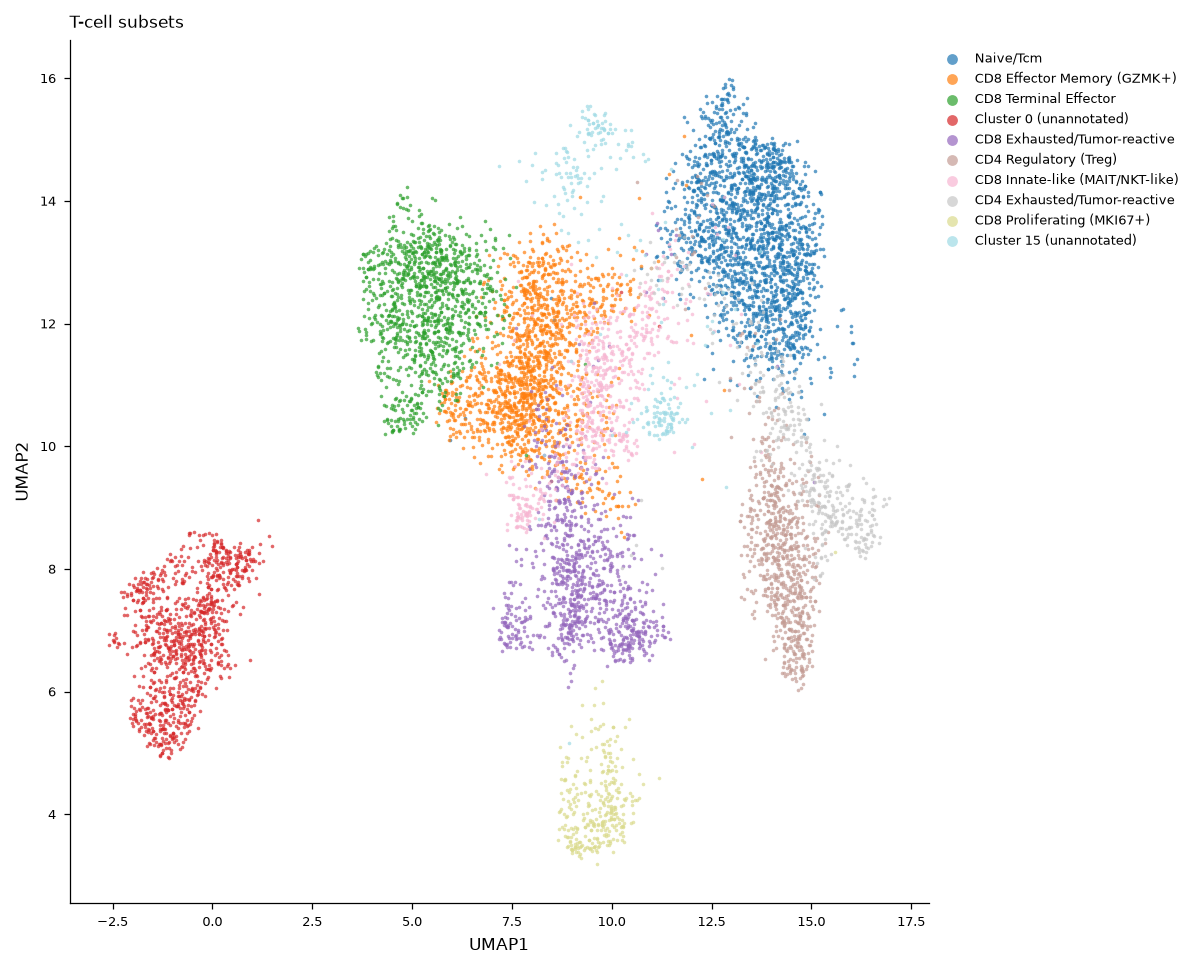

In [11]:
adata_clean = adata[~adata.obs["is_low_quality"]].copy()
print(f"Plotting {adata_clean.n_obs} clean cells (excluded {int(adata.obs['is_low_quality'].sum())} low-quality).")

groups = adata_clean.obs["subset"].astype(str).value_counts().index.tolist()
palette = plt.get_cmap("tab20")(np.linspace(0, 1, len(groups)))
color_map = dict(zip(groups, palette))
coords = adata_clean.obsm["X_umap"]

fig, ax = plt.subplots(figsize=(8, 6.5))
for g in groups:
    m = adata_clean.obs["subset"].astype(str) == g
    ax.scatter(coords[m, 0], coords[m, 1], s=3, alpha=0.7, color=color_map[g], label=g, linewidths=0)
ax.set_xlabel("UMAP1"); ax.set_ylabel("UMAP2")
ax.set_title("T-cell subsets", loc="left")
ax.legend(fontsize=6, markerscale=3, loc="upper left", bbox_to_anchor=(1.0, 1.0), frameon=False)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
fig.tight_layout()
fig.savefig(UMAP_PNG_OUT, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved {UMAP_PNG_OUT}")


## 8. Visualize: marker gene heatmap (z-scored mean expression per subset)

Saved notebook_marker_heatmap.png


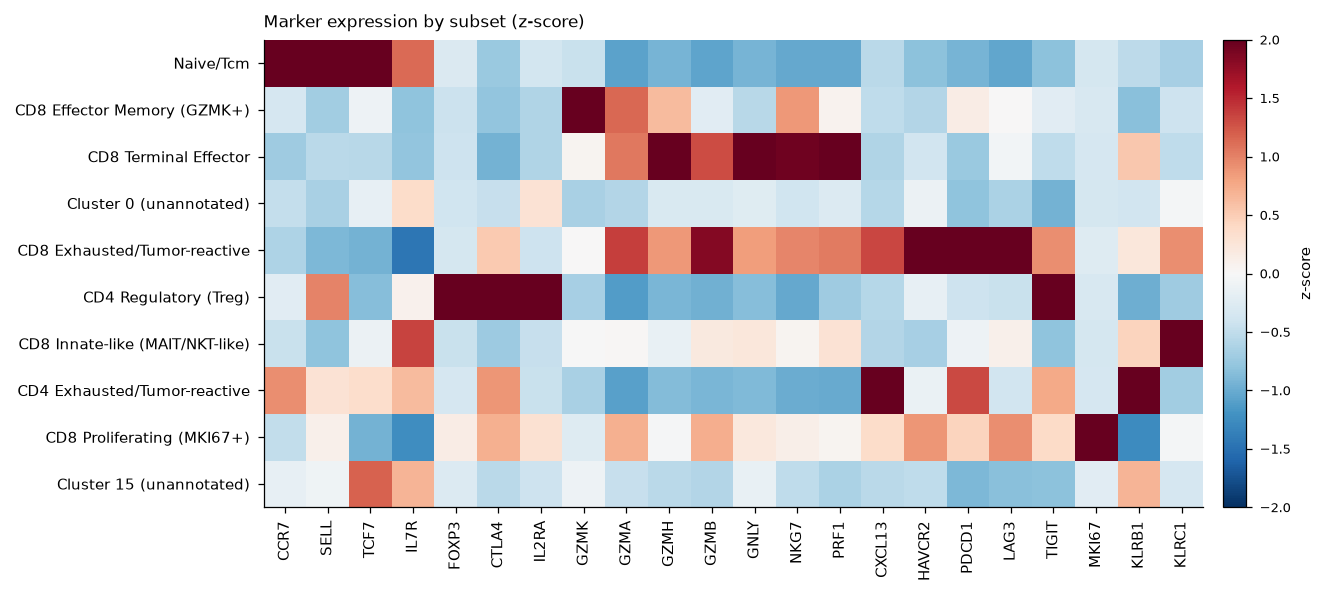

In [12]:
genes_used = [g for g in MARKER_GENES if g in adata_clean.raw.var_names]
skipped = set(MARKER_GENES) - set(genes_used)
if skipped:
    print(f"Skipped (not found in data): {sorted(skipped)}")

X = adata_clean.raw[:, genes_used].X
expr = pd.DataFrame(X.toarray() if hasattr(X, "toarray") else X, columns=genes_used, index=adata_clean.obs_names)
expr["subset"] = adata_clean.obs["subset"].values
mean_expr = expr.groupby("subset", observed=True).mean()

order = adata_clean.obs["subset"].value_counts().index
mean_expr = mean_expr.loc[[g for g in order if g in mean_expr.index]]
zscored = (mean_expr - mean_expr.mean(axis=0)) / (mean_expr.std(axis=0) + 1e-9)

fig, ax = plt.subplots(figsize=(max(6, 0.4 * len(genes_used)), max(4, 0.3 * len(zscored))))
im = ax.imshow(zscored.values, cmap="RdBu_r", vmin=-2, vmax=2, aspect="auto")
ax.set_xticks(range(len(genes_used))); ax.set_xticklabels(genes_used, rotation=90, fontsize=7)
ax.set_yticks(range(len(zscored))); ax.set_yticklabels(zscored.index, fontsize=7)
ax.set_title("Marker expression by subset (z-score)", loc="left")
cbar = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label("z-score", fontsize=7)
fig.tight_layout()
fig.savefig(HEATMAP_PNG_OUT, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved {HEATMAP_PNG_OUT}")


## 9. Visualize: marker gene dot plot (size = % expressing, color = mean expression)

Saved notebook_marker_dotplot.png


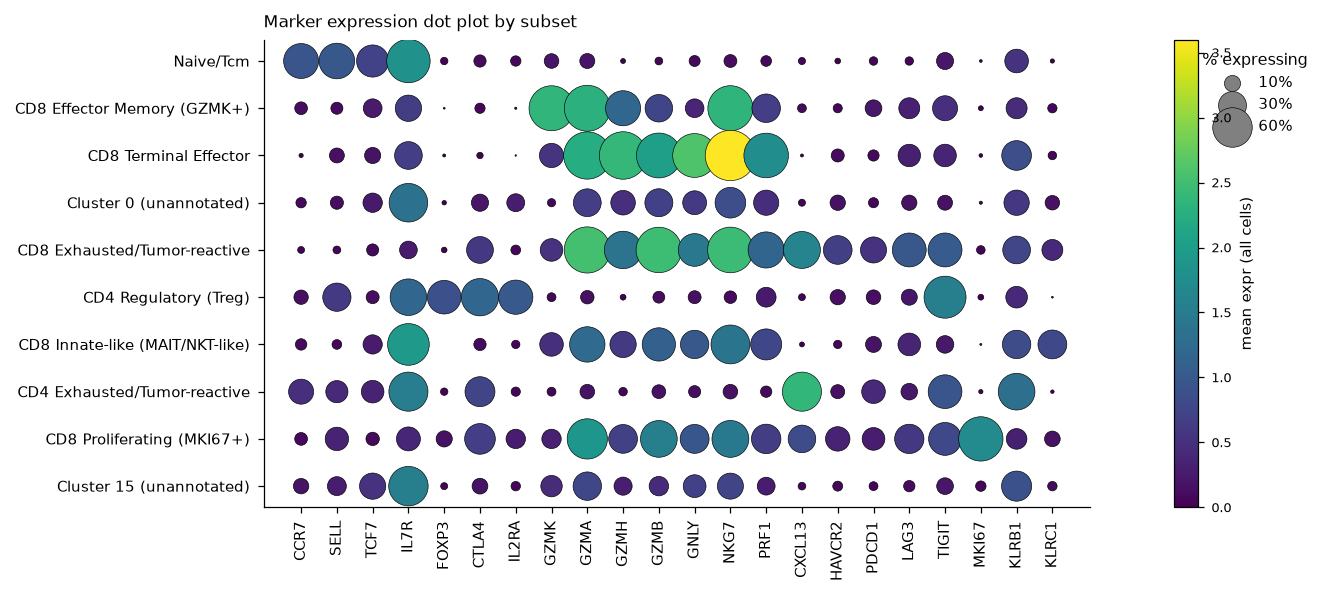

In [13]:
pct_expr = (expr.drop(columns="subset") > 0).groupby(expr["subset"], observed=True).mean() * 100
pct_expr = pct_expr.loc[mean_expr.index]

fig, ax = plt.subplots(figsize=(max(6, 0.4 * len(genes_used)), max(4, 0.3 * len(mean_expr))))
xs, ys, sizes, colors = [], [], [], []
for i, s in enumerate(mean_expr.index):
    for j, g in enumerate(genes_used):
        xs.append(j); ys.append(i)
        sizes.append(pct_expr.loc[s, g] * 6)
        colors.append(mean_expr.loc[s, g])
sc_plot = ax.scatter(xs, ys, s=sizes, c=colors, cmap="viridis", edgecolors="black", linewidths=0.3)
ax.set_xticks(range(len(genes_used))); ax.set_xticklabels(genes_used, rotation=90, fontsize=7)
ax.set_yticks(range(len(mean_expr))); ax.set_yticklabels(mean_expr.index, fontsize=7)
ax.invert_yaxis()
ax.set_title("Marker expression dot plot by subset", loc="left")
for pct_val in [10, 30, 60]:
    ax.scatter([], [], s=pct_val * 6, c="grey", edgecolors="black", linewidths=0.3, label=f"{pct_val}%")
ax.legend(title="% expressing", loc="upper left", bbox_to_anchor=(1.12, 1.0), fontsize=7, title_fontsize=7.5, frameon=False)
cbar = fig.colorbar(sc_plot, ax=ax, fraction=0.03, pad=0.09)
cbar.set_label("mean expr (all cells)", fontsize=7)
fig.tight_layout()
fig.savefig(DOTPLOT_PNG_OUT, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved {DOTPLOT_PNG_OUT}")


## 10. Summary

Outputs written by this notebook:
- `notebook_tcells_raw.h5ad` — extracted raw T cells
- `notebook_tcells_processed.h5ad` — QC'd, clustered, UMAP-embedded
- `notebook_tcells_annotated.h5ad` — with `subset` and `is_low_quality` obs columns
- `notebook_umap_by_subset.png`, `notebook_marker_heatmap.png`, `notebook_marker_dotplot.png`

To rerun on a different dataset, edit only the **Parameters** cell (Section 2) — everything else adapts automatically.

## 11. Gene of interest: Normal vs pooled-cancer comparison

Compare expression of any single gene ("GOI") between normal tissue and lung cancer
(all cancer disease labels pooled into one "Cancer" group), across the clean, annotated
T cells from Section 7.

Because many genes are sparsely/zero-inflated in single-cell data, this reports two
complementary statistics rather than a single violin plot over all cells:

- **Panel A — fraction of cells expressing the gene** (count > 0), with Wilson 95% CI
  error bars and a chi-square test on the 2x2 (group x expressing/not) contingency table.
- **Panel B — expression level among only the cells that express the gene**, with a
  Mann-Whitney U test (two groups, so we use MWU rather than Kruskal-Wallis here).

Both tests are also repeated on **donor-level pseudobulk** (one value per donor, averaged
across that donor's cells) to check whether any cell-level effect survives once
donor-level pseudoreplication is removed — a real difference should show up in both;
a cell-level-only signal may instead reflect the composition/heterogeneity of a few donors.

Edit `GOI` below and re-run the cell to check a different gene. `NORMAL_LABEL` and
`CANCER_LABELS` control which `disease` values map to which side of the comparison —
edit these if your dataset uses different disease group names.

PDCD1: fraction-expressing chi2=26.48, p=2.667e-07 | expr|detected Mann-Whitney U=39792, p=7.583e-09
Donor-level pseudobulk: fraction-expressing p=0.0031, expr|detected p=0.0775


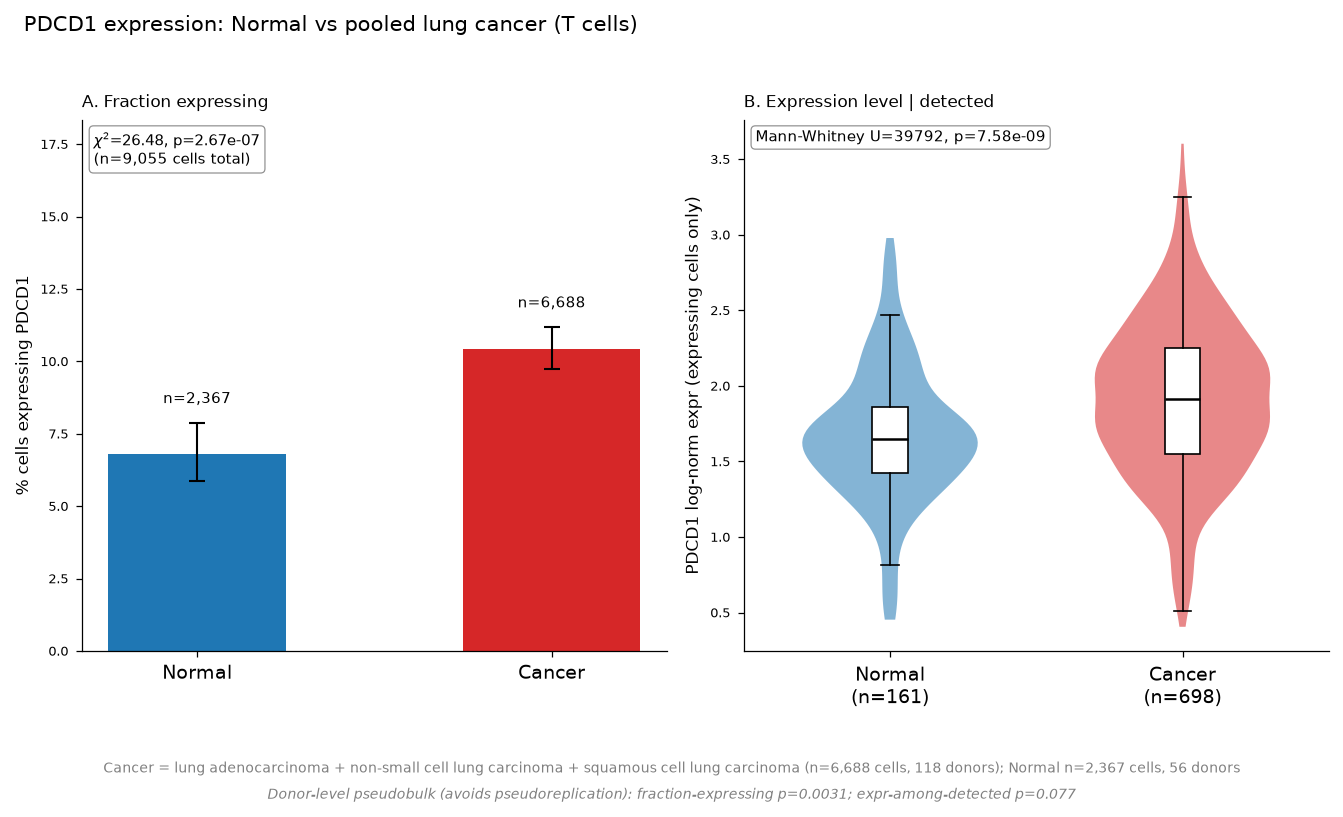

In [14]:
# --- Edit this cell to change the gene / group definitions --------------------
GOI = "PDCD1"           # <-- gene of interest; must be in adata_clean.var_names
NORMAL_LABEL = "normal"   # disease value(s) treated as "Normal"
CANCER_LABELS = [         # disease value(s) pooled into "Cancer"
    "lung adenocarcinoma",
    "non-small cell lung carcinoma",
    "squamous cell lung carcinoma",
]
# -------------------------------------------------------------------------------

import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt


def wilson_ci(k, n, z=1.96):
    """Wilson score interval for a binomial proportion, returned as (pct, lo_pct, hi_pct)."""
    if n == 0:
        return (0.0, 0.0, 0.0)
    phat = k / n
    denom = 1 + z**2 / n
    center = (phat + z**2 / (2 * n)) / denom
    half = (z * np.sqrt(phat * (1 - phat) / n + z**2 / (4 * n**2))) / denom
    return (phat * 100, (center - half) * 100, (center + half) * 100)


def compare_goi_normal_vs_cancer(adata, goi, normal_label, cancer_labels,
                                  layer="lognorm", disease_col="disease",
                                  donor_col="donor_id", savepath=None):
    """Compare expression of `goi` between a normal group and a pooled cancer group.

    Returns a dict of computed statistics and the matplotlib Figure. Raises a
    clear error if `goi` is not present in `adata.raw.var_names` so a typo'd
    gene name fails loudly rather than silently plotting nothing.
    """
    if goi not in adata.var_names:
        raise ValueError(
            f"Gene '{goi}' not found in adata.var_names. "
            f"Check spelling/case (gene symbols are case-sensitive)."
        )

    gene_idx = adata.var_names.get_loc(goi)
    mat = adata.layers[layer] if layer in adata.layers else adata.X
    col = mat[:, gene_idx]
    expr_vals = np.asarray(col.todense()).ravel() if hasattr(col, "todense") else np.asarray(col).ravel()

    df = pd.DataFrame({
        "expr": expr_vals,
        "disease": adata.obs[disease_col].values,
        "donor_id": adata.obs[donor_col].values,
    })
    df["group"] = pd.Series(pd.NA, index=df.index, dtype="object")
    df.loc[df["disease"] == normal_label, "group"] = "Normal"
    df.loc[df["disease"].isin(cancer_labels), "group"] = "Cancer"
    df = df.dropna(subset=["group"]).copy()
    df["expressing"] = df["expr"] > 0
    group_order = ["Normal", "Cancer"]
    n_per_group = df["group"].value_counts().to_dict()

    # --- Fraction expressing + Wilson CI + chi-square ---
    cis = {}
    for g in group_order:
        sub = df[df.group == g]
        k, n = int(sub["expressing"].sum()), len(sub)
        cis[g] = wilson_ci(k, n)
    cont = np.array([[df[df.group == g]["expressing"].sum(),
                       len(df[df.group == g]) - df[df.group == g]["expressing"].sum()]
                      for g in group_order])
    chi2, p_chi2, dof, _ = stats.chi2_contingency(cont)

    # --- Expression among expressing cells + Mann-Whitney U ---
    groups_pos = [df[(df.group == g) & df["expressing"]]["expr"].values for g in group_order]
    if all(len(g) > 0 for g in groups_pos):
        U_stat, p_mw = stats.mannwhitneyu(groups_pos[0], groups_pos[1], alternative="two-sided")
    else:
        U_stat, p_mw = np.nan, np.nan

    # --- Donor-level pseudobulk checks ---
    donor_frac = df.groupby(["donor_id", "group"], observed=True)["expressing"].mean().reset_index()
    normal_donor_frac = donor_frac[donor_frac.group == "Normal"]["expressing"].values
    cancer_donor_frac = donor_frac[donor_frac.group == "Cancer"]["expressing"].values
    if len(normal_donor_frac) > 1 and len(cancer_donor_frac) > 1:
        _, p_donor_frac = stats.mannwhitneyu(normal_donor_frac, cancer_donor_frac, alternative="two-sided")
    else:
        p_donor_frac = np.nan

    donor_expr_pos = df[df.expressing].groupby(["donor_id", "group"], observed=True)["expr"].mean().reset_index()
    normal_donor_expr = donor_expr_pos[donor_expr_pos.group == "Normal"]["expr"].values
    cancer_donor_expr = donor_expr_pos[donor_expr_pos.group == "Cancer"]["expr"].values
    if len(normal_donor_expr) > 1 and len(cancer_donor_expr) > 1:
        _, p_donor_expr = stats.mannwhitneyu(normal_donor_expr, cancer_donor_expr, alternative="two-sided")
    else:
        p_donor_expr = np.nan

    # --- Figure ---
    apply_figure_style()
    fig, axes = plt.subplots(1, 2, figsize=(9, 5))
    palette = ["#1f77b4", "#d62728"]
    positions = np.arange(len(group_order))

    ax = axes[0]
    pcts = [cis[g][0] for g in group_order]
    los = [cis[g][0] - cis[g][1] for g in group_order]
    his = [cis[g][2] - cis[g][0] for g in group_order]
    ax.bar(positions, pcts, color=palette, width=0.5, yerr=[los, his], capsize=4,
           error_kw=dict(lw=1, ecolor="black"))
    ax.set_xticks(positions)
    ax.set_xticklabels(group_order, fontsize=9)
    ax.set_ylabel(f"% cells expressing {goi}")
    ax.set_title("A. Fraction expressing", loc="left")
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)
    y_top = max(pcts[i] + his[i] for i in range(len(group_order)))
    ax.set_ylim(0, y_top * 1.55 + 1)
    ax.text(0.02, 0.98, f"$\\chi^2$={chi2:.2f}, p={p_chi2:.2e}\n(n={len(df):,} cells total)",
            transform=ax.transAxes, fontsize=7, va="top", ha="left",
            bbox=dict(boxstyle="round", facecolor="white", edgecolor="grey", alpha=0.85))
    for i, g in enumerate(group_order):
        ax.text(i, pcts[i] + his[i] + y_top * 0.06, f"n={n_per_group[g]:,}", ha="center", fontsize=7)

    ax = axes[1]
    if all(len(g) > 0 for g in groups_pos):
        parts = ax.violinplot(groups_pos, positions=positions, showmeans=False, showmedians=False,
                               showextrema=False, widths=0.6)
        for i, pc in enumerate(parts["bodies"]):
            pc.set_facecolor(palette[i]); pc.set_alpha(0.55); pc.set_edgecolor("none")
        ax.boxplot(groups_pos, positions=positions, widths=0.12, showfliers=False, patch_artist=True,
                   medianprops=dict(color="black", lw=1.2),
                   boxprops=dict(facecolor="white", edgecolor="black", lw=0.8),
                   whiskerprops=dict(color="black", lw=0.8), capprops=dict(color="black", lw=0.8))
    ax.set_xticks(positions)
    ax.set_xticklabels([f"{group_order[i]}\n(n={len(groups_pos[i])})" for i in range(len(group_order))], fontsize=9)
    ax.set_ylabel(f"{goi} log-norm expr (expressing cells only)")
    ax.set_title("B. Expression level | detected", loc="left")
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)
    ax.text(0.02, 0.98, f"Mann-Whitney U={U_stat:.0f}, p={p_mw:.2e}" if not np.isnan(U_stat) else "insufficient data",
            transform=ax.transAxes, fontsize=7, va="top", ha="left",
            bbox=dict(boxstyle="round", facecolor="white", edgecolor="grey", alpha=0.85))

    fig.suptitle(f"{goi} expression: Normal vs pooled lung cancer (T cells)", fontsize=10, x=0.02, ha="left")
    fig.text(0.5, -0.03,
              f"Cancer = {' + '.join(cancer_labels)} (n={n_per_group.get('Cancer', 0):,} cells, "
              f"{df[df.group=='Cancer']['donor_id'].nunique()} donors); "
              f"Normal n={n_per_group.get('Normal', 0):,} cells, {df[df.group=='Normal']['donor_id'].nunique()} donors",
              fontsize=6.5, ha="center", color="grey")
    fig.text(0.5, -0.065,
              f"Donor-level pseudobulk (avoids pseudoreplication): fraction-expressing p={p_donor_frac:.2g}; "
              f"expr-among-detected p={p_donor_expr:.2g}",
              fontsize=6.5, ha="center", color="grey", style="italic")
    fig.tight_layout(rect=[0, 0.03, 1, 0.95])
    if savepath:
        fig.savefig(savepath, dpi=200, bbox_inches="tight")
    plt.show()

    return {
        "goi": goi, "df": df, "n_per_group": n_per_group,
        "chi2": chi2, "p_chi2": p_chi2,
        "U_stat": U_stat, "p_mw": p_mw,
        "p_donor_frac": p_donor_frac, "p_donor_expr": p_donor_expr,
        "fig": fig,
    }


results = compare_goi_normal_vs_cancer(
    adata_clean, GOI, NORMAL_LABEL, CANCER_LABELS,
    savepath=f"goi_{GOI}_normal_vs_cancer.png",
)
print(f"{GOI}: fraction-expressing chi2={results['chi2']:.2f}, p={results['p_chi2']:.3e} "
      f"| expr|detected Mann-Whitney U={results['U_stat']:.0f}, p={results['p_mw']:.3e}")
print(f"Donor-level pseudobulk: fraction-expressing p={results['p_donor_frac']:.3g}, "
      f"expr|detected p={results['p_donor_expr']:.3g}")